## Домашнее задание 4

Мы продолжаем работу над визуализацией. В этот раз нужно создать визуализации результатов работы алгоритмов обучения с учителем и без учителя, проанализировать изменения параметров и ROC-кривых при изменении гиперпараметров модели, обсудить различия в результатах работы моделей.

Будем работать с тремя датасетами. Перед каждым заданием будет его описание.

Не пугайтесь количеству импортированных библиотек — это шпаргалка со всеми библиотеками, которые мы использовали в четвертом модуле. В этом задании будем использовать несколько из них.

In [38]:
# !pip install pyod

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import IsolationForest, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import OneClassSVM, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification, make_moons, make_circles, make_blobs
from scipy.stats import norm
from sklearn.metrics import confusion_matrix, classification_report, f1_score, make_scorer, precision_score, recall_score, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.cluster import DBSCAN, SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min
from pyod.models.hbos import HBOS

import warnings
warnings.filterwarnings('ignore')

Первый датасет — данные по весу и росту в зависимости от пола. В нем нет разметки, поэтому необходимо использовать методы обучения без учителя.

Импортируем датасет и визуально посмотрим на него перед началом работы:

In [40]:
weight_height = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/weight-height.csv')
weight_height.head(10)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
7,Male,68.348516,167.971110
8,Male,67.018950,175.929440
9,Male,63.456494,156.399676


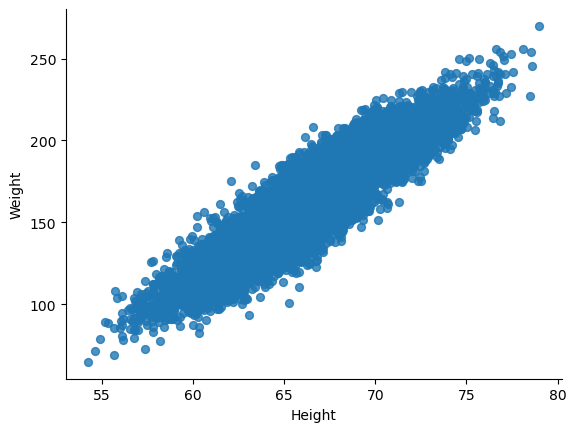

In [41]:
weight_height.plot(kind='scatter', x='Height', y='Weight', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

---

## Задание 1. Сравнение моделей обучения с учителем (6 баллов)

Используя разные алгоритмы машинного обучения, проанализируйте наш датасет на наличие выбросов и аномалий. В качестве переменных для анализа используйте только вес и рост.

Создайте поле из 6 графиков. Каждый график (scatter plot) должен иметь заголовок, названия полей, прозрачность точек 0.8. Должны отсутствовать рамки со всех сторон. Пометьте аномалии красным цветом, а все остальные данные — зеленым.

Поместите на графики следующие 6 алгоритмов:
- Interquartile range (IQR) — возьмите выбросы по `x` и `y`.
- Isolation forest.
- Local Outlier Factor.
- One-class SVM.
- Gaussian Mixture.
- DBSCAN.

Напишите, какие модели показали себя лучше всего и почему.

**Критерии оценивания:**

- 1 балл за каждую правильно построенную модель и корректно выведенные выбросы (всего 3 балла).
- 1 балл за правильное оформление графиков и полотна графиков.

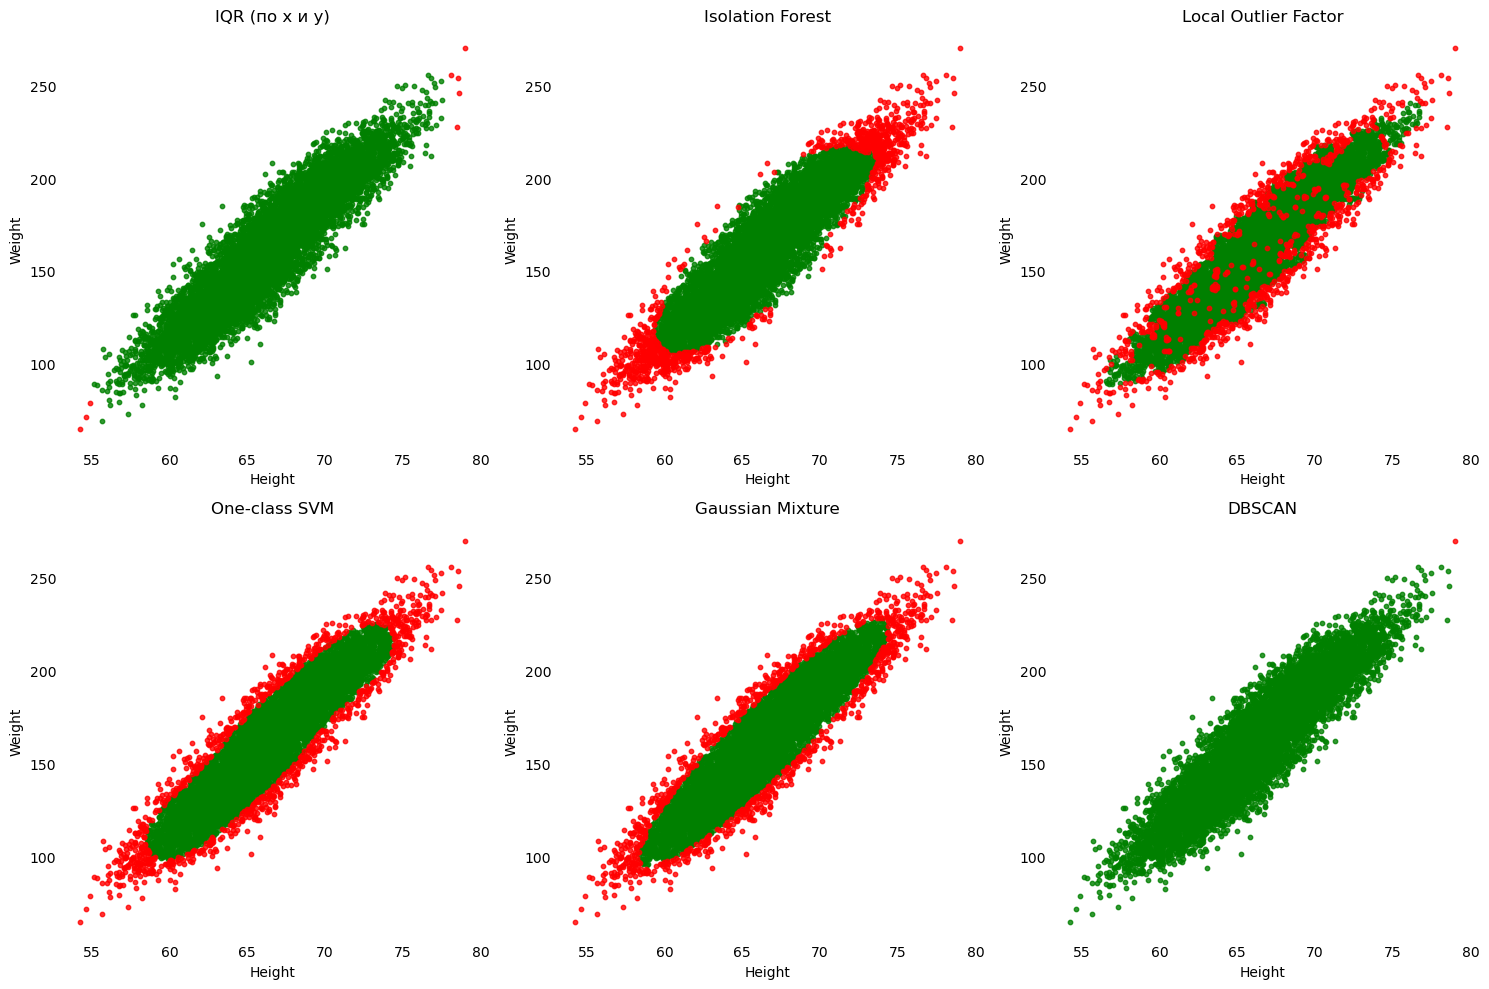

In [42]:
X = weight_height[['Height', 'Weight']].copy()

# Стандартизация для алгоритмов, чувствительных к масштабу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


def iqr_outliers(data):
    """IQR выбросы по каждой оси (объединение)"""
    q1_h = data['Height'].quantile(0.25)
    q3_h = data['Height'].quantile(0.75)
    iqr_h = q3_h - q1_h
    lower_h = q1_h - 1.5 * iqr_h
    upper_h = q3_h + 1.5 * iqr_h

    q1_w = data['Weight'].quantile(0.25)
    q3_w = data['Weight'].quantile(0.75)
    iqr_w = q3_w - q1_w
    lower_w = q1_w - 1.5 * iqr_w
    upper_w = q3_w + 1.5 * iqr_w

    outlier_mask = (data['Height'] < lower_h) | (data['Height'] > upper_h) | \
                   (data['Weight'] < lower_w) | (data['Weight'] > upper_w)
    return outlier_mask

def isolation_forest_outliers(X_scaled):
    model = IsolationForest(contamination=0.1, random_state=42)
    preds = model.fit_predict(X_scaled)
    return preds == -1

def lof_outliers(X_scaled):
    model = LocalOutlierFactor(contamination=0.1)
    preds = model.fit_predict(X_scaled)
    return preds == -1

def svm_outliers(X_scaled):
    model = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
    preds = model.fit_predict(X_scaled)
    return preds == -1

def gmm_outliers(X_scaled):
    model = GaussianMixture(n_components=1, random_state=42)
    model.fit(X_scaled)
    scores = model.score_samples(X_scaled)
    threshold = np.percentile(scores, 10)  # нижние 10% считаем выбросами
    return scores < threshold

def dbscan_outliers(X_scaled):
    model = DBSCAN(eps=0.5, min_samples=10)
    labels = model.fit_predict(X_scaled)
    return labels == -1  # -1 означает шум (выброс)

# Список кортежей: (функция, заголовок)
algorithms = [
    (lambda: iqr_outliers(X), 'IQR (по x и y)'),
    (lambda: isolation_forest_outliers(X_scaled), 'Isolation Forest'),
    (lambda: lof_outliers(X_scaled), 'Local Outlier Factor'),
    (lambda: svm_outliers(X_scaled), 'One-class SVM'),
    (lambda: gmm_outliers(X_scaled), 'Gaussian Mixture'),
    (lambda: dbscan_outliers(X_scaled), 'DBSCAN')
]

# Создание поля
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (outlier_func, title) in zip(axes, algorithms):
    outlier_mask = outlier_func()

    # Нормальные точки (зеленые)
    ax.scatter(X.loc[~outlier_mask, 'Height'], X.loc[~outlier_mask, 'Weight'],
               c='green', alpha=0.8, s=10, label='Нормальные')
    # Аномалии (красные)
    ax.scatter(X.loc[outlier_mask, 'Height'], X.loc[outlier_mask, 'Weight'],
               c='red', alpha=0.8, s=10, label='Аномалии')

    ax.set_title(title)
    ax.set_xlabel('Height')
    ax.set_ylabel('Weight')

    # Убираем рамки
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Убираем засечки (ticks)
    ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

> Можно наблюдать следующие моменты:
- IQR - отсечение выбросов по границе распределения
- Isolation Forest - формирование внутреннего кластера с агрессивным отсечением границ
- Local Outlier Factor - в 2d пространстве отсечение граничных точек и части точек внутри блоба, что может говорить о том, что аномалии внутри это проекции точек из 3d, необходимо дальнейшее исследование, так как то что на первый взгляд является ошибкой, может, в действительности быть инсайтом.
- One Class SVM - подобие IF, но более аггрессивное усичение 
- Gaussian Mixture - отсечение по границам распределения
- DBSCAN - нашел только одну отстоящую аномалию, что ожидаемо учитывая то, что он ориентируется на плотность

---

## Задания 2 и 3

Используя датасет, определите оптимальные параметры модели Isolation Forest с помощью кросс-валидации.

Наш датасет — это набор данных, первоначально взятый [из набора данных UCI](https://dataverse.harvard.edu/file.xhtml?persistentId=doi:10.7910/DVN/OPQMVF/CJURKL&version=1.0) о заболеваниях щитовидной железы. Он содержит 16 категориальных атрибутов, 5 числовых атрибутов и 1 целевой атрибут. Всего — 22 атрибута.

In [43]:
thyroid = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/annthyroid_unsupervised_anomaly_detection.csv', sep=';').iloc[:, :-2]
thyroid.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o


In [44]:
thyroid["Outlier_label "].value_counts(normalize=True)

Outlier_label 
n    0.963852
o    0.036148
Name: proportion, dtype: float64

> Предварительно посмотрим на сбалансированность классов

---

## Задание 2. Проверка влияния параметров Isolation Forest на итоговые параметры (4 балла)

После обучения модели выполните следующее:

- Обучите модель Isolation Forest на данных Х с использованием найденных оптимальных параметров (для этого оберните Isolation Forest в [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)). В `GridSearchCV` используйте `params = {'n_estimators': list(range(5, 15)), 'max_features': list(range(2, 10))}`.
- Сделайте предсказания на данных Х.
- Поиграйте с параметром `n_jobs` — создайте 6 разных визуализаций с параметрами от 1 до 6.
- Замените значения предсказаний, где 1 соответствует «нормальному» наблюдению (normal), а -1 — «выбросу» (outlier).
- Выведите лучшие параметры модели Isolation Forest для всех 6 параметров (для лучшего понимания оформите выводы).

**Критерии оценивания:**
- 1 балл за правильное использование `GridSearchCV` для подбора параметров в `IsolationForest`.
- 1 балл за правильный вывод параметров для шести моделей с разным параметром `n_jobs`.



Запуск GridSearchCV с n_jobs = 1...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 2...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 3...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 4...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 5...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 6...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}


Лучшие параметры для каждого значения n_jobs:
n_jobs = 1: {'max_features': 2, 'n_estimators': 13}
n_jobs = 2: {'max_features': 2, 'n_estimators': 13}
n_jobs = 3: {'max_features': 2, 'n_estimators': 13}
n_jobs = 4: {'max_features': 2, 'n_estimators': 13}
n_jobs = 5: {'max_features': 2, 'n_estimators': 13}
n_jobs = 6: {'max_features': 2, 'n_estimators': 13}


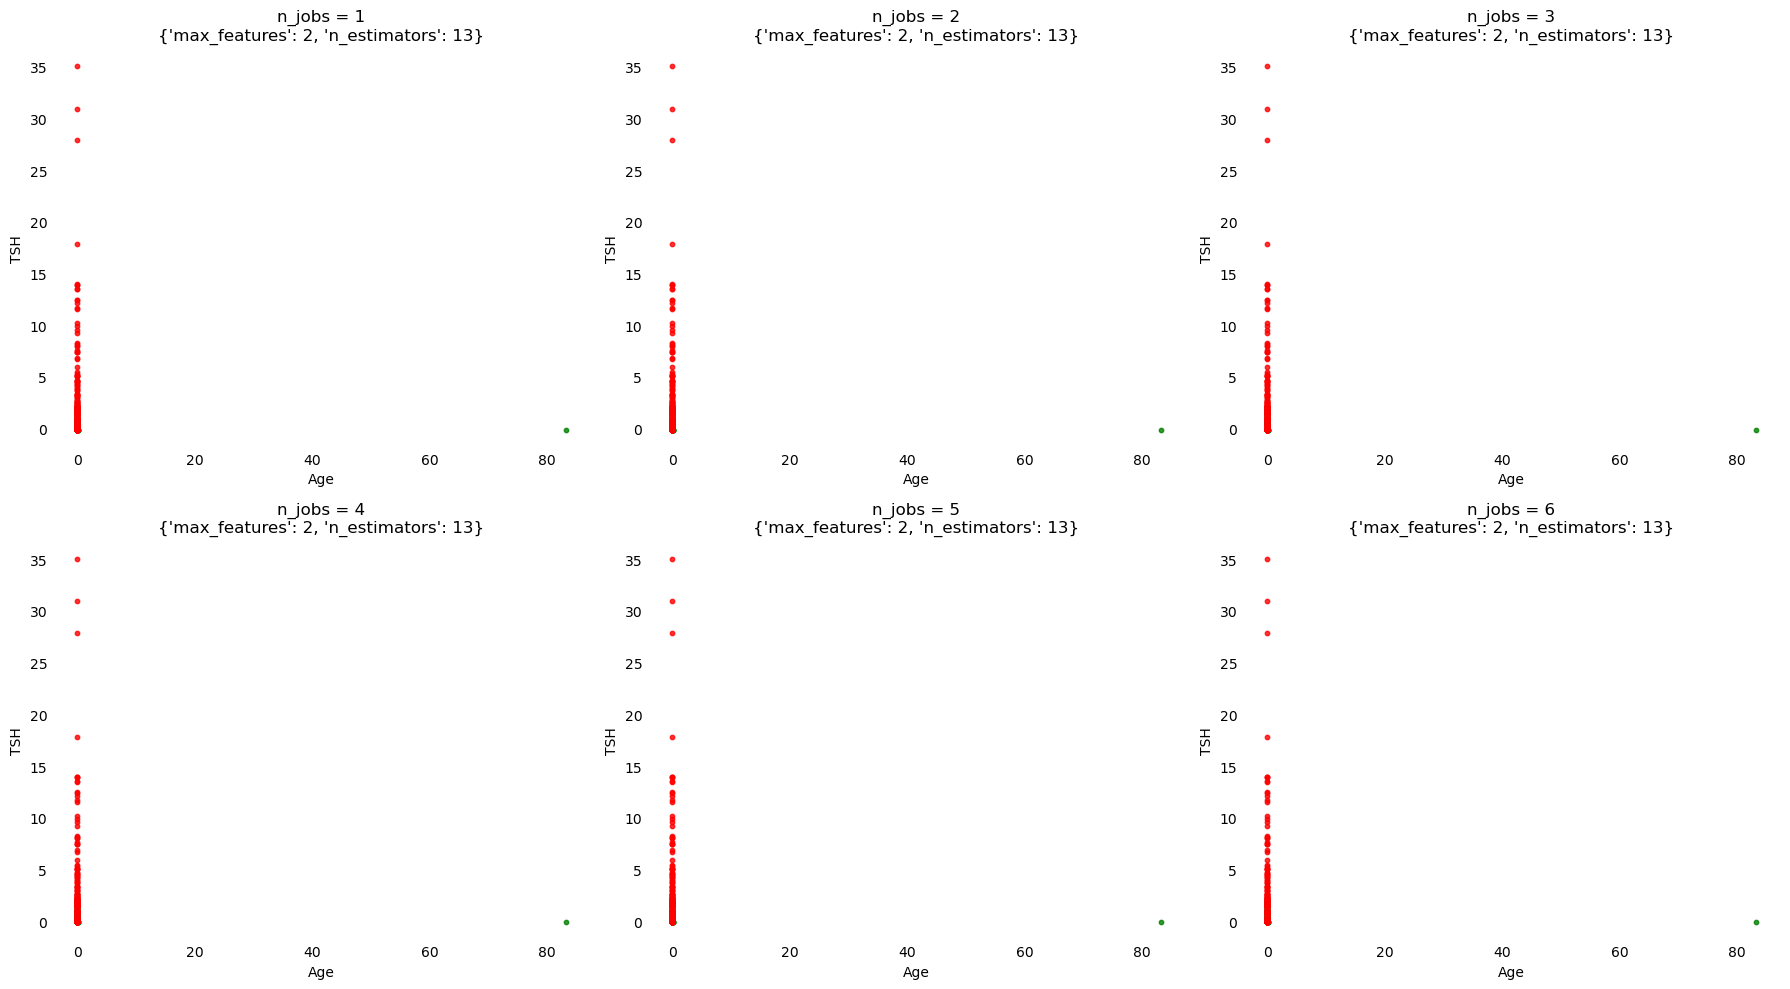

In [45]:
X = thyroid.iloc[:, :-1].copy()
y = thyroid.iloc[:, -1].copy()

# Преобразуем метки: 'o' – аномалия (1), остальное – норма (0)
y_binary = (y == 'o').astype(int)

# 2. Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # для удобства визуализации

# Определяем сетку параметров
param_grid = {
    'n_estimators': list(range(5, 15)),
    'max_features': list(range(2, 10))
}

# baseline
base_model = IsolationForest(random_state=42, contamination='auto', bootstrap=False)

# scorer для f1
def custom_f1(y_true, y_pred):
    y_pred_bin = (y_pred == -1).astype(int)
    return f1_score(y_true, y_pred_bin)

f1_scorer = make_scorer(custom_f1, greater_is_better=True)

# Для каждого n_jobs от 1 до 6 выполняем GridSearchCV
n_jobs_values = range(1, 7)
best_models = []
best_params_list = []

for nj in n_jobs_values:
    print(f"Запуск GridSearchCV с n_jobs = {nj}...")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=f1_scorer,
        cv=cv,
        n_jobs=nj,
        verbose=0,
        refit=True
    )
    gs.fit(X_scaled, y_binary)

    best_models.append(gs.best_estimator_)
    best_params_list.append(gs.best_params_)
    print(f"  Лучшие параметры: {gs.best_params_}\n")

# Вывод лучших параметров
print("\n" + "="*60)
print("Лучшие параметры для каждого значения n_jobs:")
for nj, params in zip(n_jobs_values, best_params_list):
    print(f"n_jobs = {nj}: {params}")
print("="*60)

# Визуализация предсказаний 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

feature_x = 'Age'
feature_y = 'TSH'

for idx, (nj, model) in enumerate(zip(n_jobs_values, best_models)):
    # Предсказание на всех данных
    preds = model.predict(X_scaled)   # 1 - норма, -1 - аномалия
    outlier_mask = (preds == -1)

    ax = axes[idx]
    # Нормальные точки 
    ax.scatter(X_scaled.loc[~outlier_mask, feature_x],
               X_scaled.loc[~outlier_mask, feature_y],
               c='green', alpha=0.8, s=10, label='Норма')
    # Аномалии 
    ax.scatter(X_scaled.loc[outlier_mask, feature_x],
               X_scaled.loc[outlier_mask, feature_y],
               c='red', alpha=0.8, s=10, label='Аномалия')

    ax.set_title(f'n_jobs = {nj}\n{best_params_list[idx]}')
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)

    # Убираем рамки
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

> Выводы: Лучшие параметры не зависят от njobs, что ожидаемо приводит к идентичности графиков

---

## Задание 3. Визуализация ROC-кривой в зависимости от параметров Isolation Forest (4 балла)

- Для каждого Isolation Forest создайте отдельную `roc_curve` и полотно с шестью графиками для визуализации шести ROC-кривых в зависимости от параметра n_jobs.
- В название каждого графика выведите F1-score, Precision и Recall для каждой модели Isolation Forest.

**Критерии оценивания:**

- 1 балл за правильно построенные визуализации ROC-кривой.
- 1 балл за вывод правильных F1-score, Precision, Recall.

Запуск GridSearchCV с n_jobs = 1...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 2...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 3...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 4...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 5...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}

Запуск GridSearchCV с n_jobs = 6...
  Лучшие параметры: {'max_features': 2, 'n_estimators': 13}


Лучшие параметры для каждого значения n_jobs:
n_jobs = 1: {'max_features': 2, 'n_estimators': 13}
n_jobs = 2: {'max_features': 2, 'n_estimators': 13}
n_jobs = 3: {'max_features': 2, 'n_estimators': 13}
n_jobs = 4: {'max_features': 2, 'n_estimators': 13}
n_jobs = 5: {'max_features': 2, 'n_estimators': 13}
n_jobs = 6: {'max_features': 2, 'n_estimators': 13}


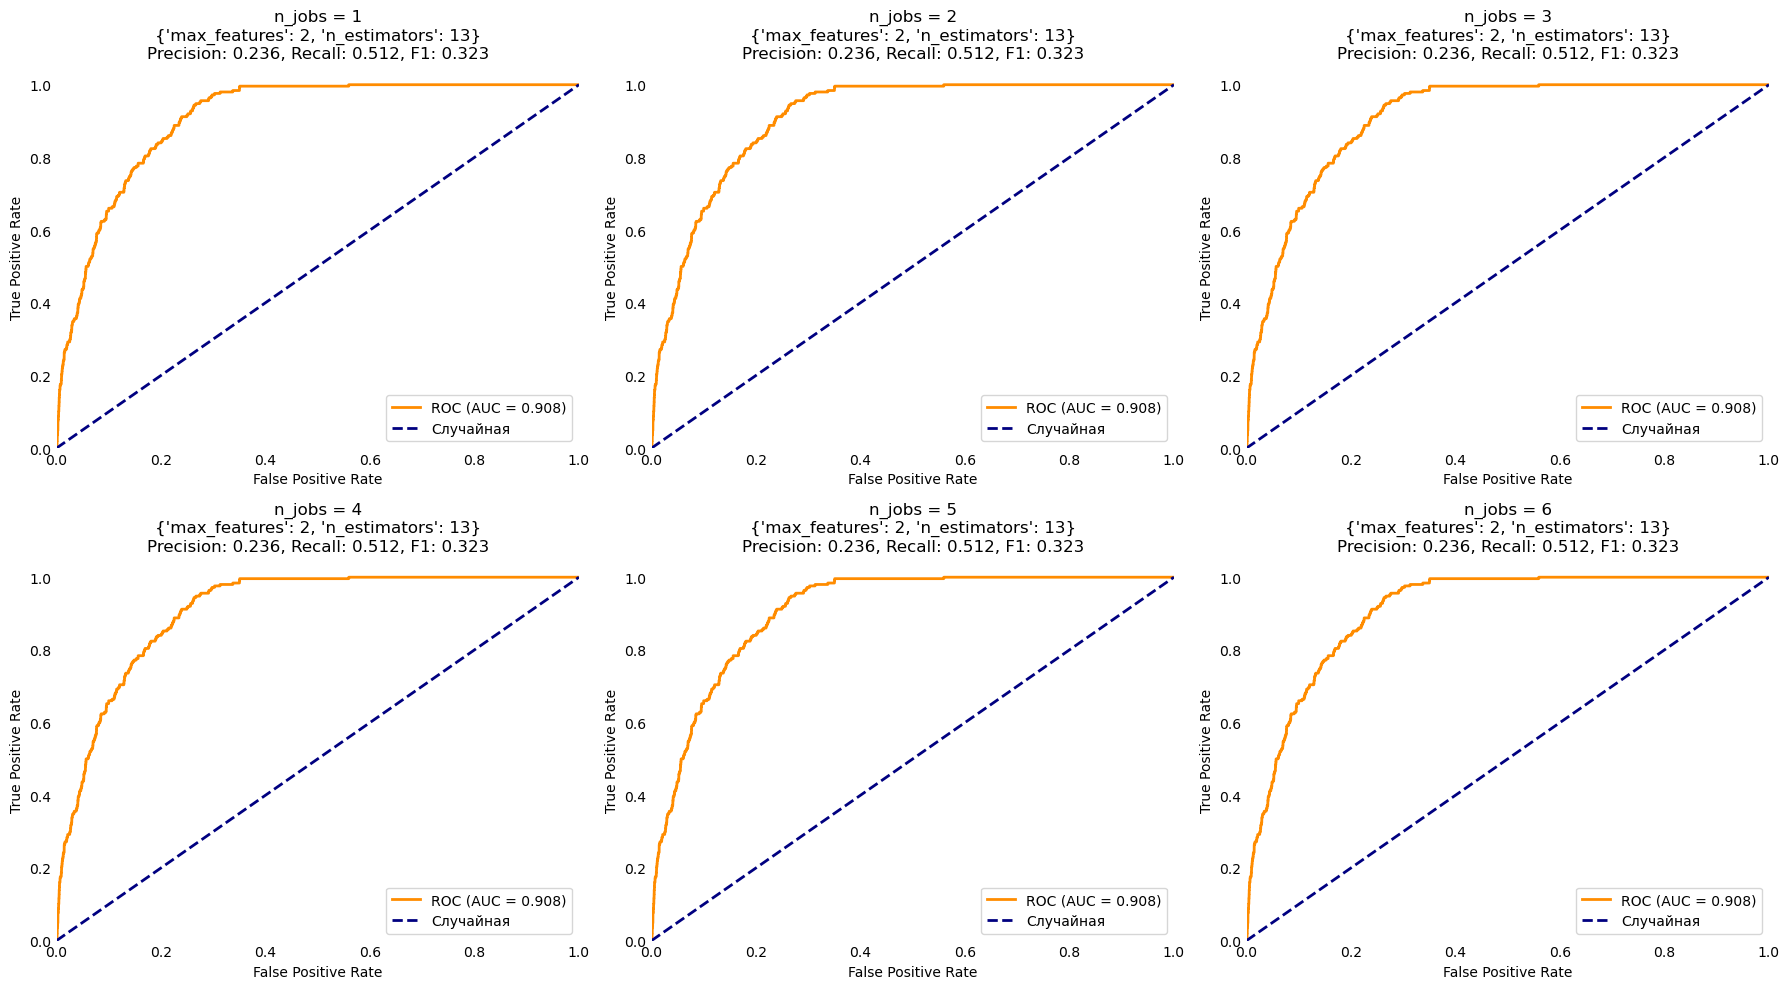

In [46]:
X = thyroid.iloc[:, :-1].copy()
y = thyroid.iloc[:, -1].copy()

# Преобразуем метки
y_binary = (y == 'o').astype(int)

# 2. Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Определяем сетку параметров
param_grid = {
    'n_estimators': list(range(5, 15)),
    'max_features': list(range(2, 10))
}

# baseline
base_model = IsolationForest(random_state=42, contamination='auto', bootstrap=False)

# scorer для f1 
def custom_f1(y_true, y_pred):
    y_pred_bin = (y_pred == -1).astype(int)
    return f1_score(y_true, y_pred_bin)

f1_scorer = make_scorer(custom_f1, greater_is_better=True)

# Для каждого n_jobs от 1 до 6 выполняем GridSearchCV
n_jobs_values = range(1, 7)
best_models = []
best_params_list = []

for nj in n_jobs_values:
    print(f"Запуск GridSearchCV с n_jobs = {nj}...")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=f1_scorer,
        cv=cv,
        n_jobs=nj,
        verbose=0,
        refit=True
    )
    gs.fit(X_scaled, y_binary)

    best_models.append(gs.best_estimator_)
    best_params_list.append(gs.best_params_)
    print(f"  Лучшие параметры: {gs.best_params_}\n")

# Вывод лучших параметров
print("\n" + "="*60)
print("Лучшие параметры для каждого значения n_jobs:")
for nj, params in zip(n_jobs_values, best_params_list):
    print(f"n_jobs = {nj}: {params}")
print("="*60)

# Построение ROC-кривых для каждой модели
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (nj, model) in enumerate(zip(n_jobs_values, best_models)):
    # Предсказания и метрики
    preds = model.predict(X_scaled)
    y_pred_bin = (preds == -1).astype(int)
    
    precision = precision_score(y_binary, y_pred_bin)
    recall = recall_score(y_binary, y_pred_bin)
    f1 = f1_score(y_binary, y_pred_bin)
    
    anomaly_scores = -model.decision_function(X_scaled)
    
    fpr, tpr, _ = roc_curve(y_binary, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    
    ax = axes[idx]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'n_jobs = {nj}\n{best_params_list[idx]}\n'
                 f'Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}')
    ax.legend(loc='lower right')
    
    # Убираем рамки
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

> Выводы: Лучшие параметры не зависят от njobs, что ожидаемо приводит к идентичности графиков. Из-за дисбаланса классов есть вероятность что все алгоритмы переобучились

---

## Задание 4. Проверка эффективности моделей без учителя (6 баллов)

Ранее мы обсуждали, что методы обучения с учителем можно использовать не только для поиска аномалий, но и для классической классификации. Аналогично первому заданию, используя разные алгоритмы обучения с учителем, постройте модель для классификации по данным датасета.

Наш третий датасет — данные по принятым и не принятым в университет студентам в зависимости от их среднего балла и балла за экзамен.
В качестве переменных для анализа используйте средний балл (**cgpa**) и балл за экзамен (**placement_exam_marks**), а в качестве зависимой переменной в кластеризации используйте переменную **placed**.

Создайте поле из шести графиков. Каждый график должен представлять собой confusion_matrix (heatmap или тепловую карту) с попаданиями модели (матрица 2 на 2 с попаданиями модели, как делали на третьей неделе). Каждый график должен иметь заголовок и названия полей. На тепловой карте на каждом квадратике должно быть указано число, а также colorbar с правой стороны.

Поместите на графики следующие 6 алгоритмов:
- k-Nearest Neighbors (KNN).
- SVM (Support Vector Machine).
- Random Forest.
- AdaBoost.
- Gradient Boosting.
- Decision Tree.

**Критерии оценивания:**

- 1 балл за каждые две правильно построенные модели и корректно выведенные выбросы.
- 1 балл за правильное оформление графиков и полотна графиков.

In [47]:
placement = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/placement.csv')
placement.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


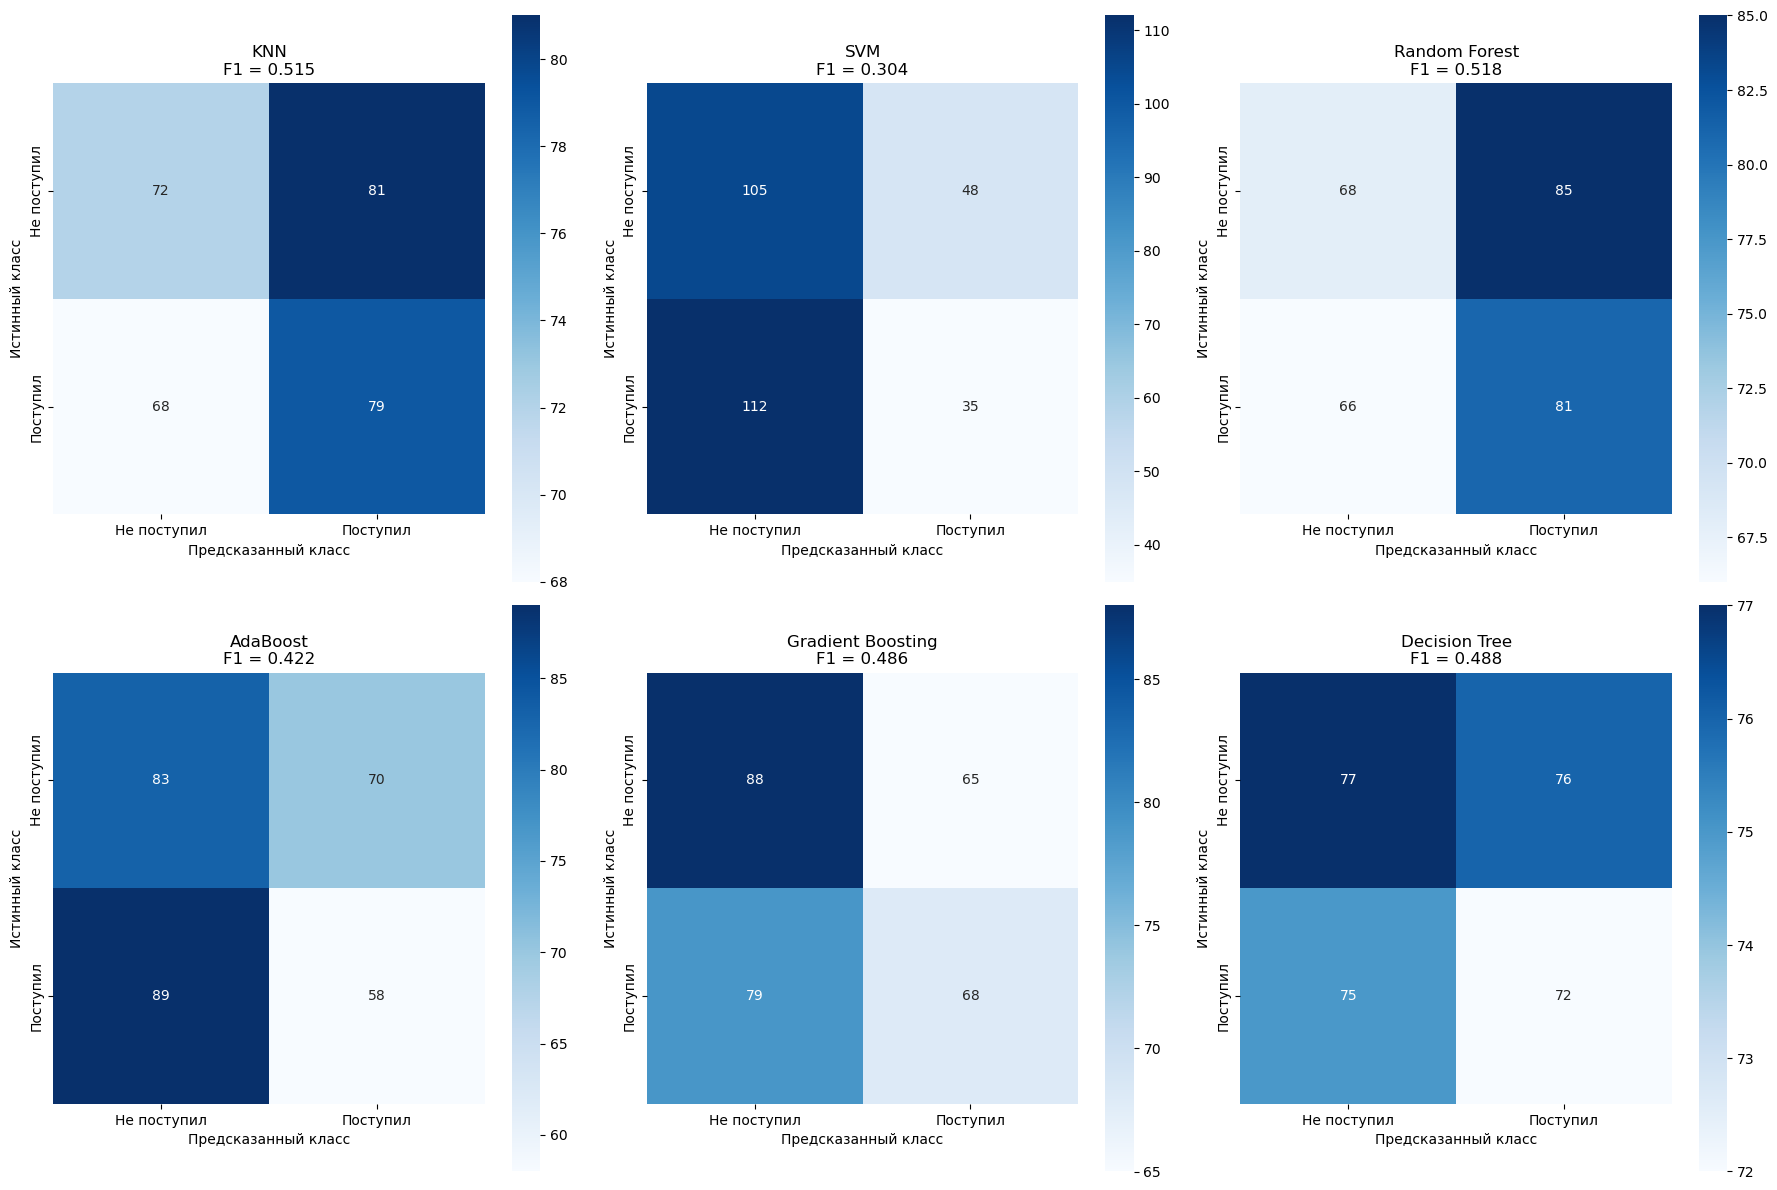

In [51]:
np.random.seed(42)

# Признаки и целевая переменная
X = placement[['cgpa', 'placement_exam_marks']]
y = placement['placed']

# Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

# Модели с флагом необходимости масштабирования
models = [
    ('KNN', KNeighborsClassifier(), True),
    ('SVM', SVC(random_state=42), True),
    ('Random Forest', RandomForestClassifier(random_state=42), False),
    ('AdaBoost', AdaBoostClassifier(random_state=42), False),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42), False),
    ('Decision Tree', DecisionTreeClassifier(random_state=42), False)
]

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, model, use_scale) in zip(axes.ravel(), models):
    X_tr, X_te = (X_train_scaled, X_test_scaled) if use_scale else (X_train, X_test)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Не поступил', 'Поступил'],
                yticklabels=['Не поступил', 'Поступил'], ax=ax, square=True)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    ax.set_title(f'{name}\nF1 = {f1:.3f}')

plt.tight_layout()
plt.show()

> В целом все алгоритмы отработали на уровне ромашки. Что впринципе можно обосновать хотя бы табличным выводом первых пяти значений, где мы видим (скопировал из вывода консоли):
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>cgpa</th>
      <th>placement_exam_marks</th>
      <th>placed</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>7.19</td>
      <td>26.0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>1</th>
      <td>7.46</td>
      <td>38.0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>2</th>
      <td>7.54</td>
      <td>40.0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>3</th>
      <td>6.42</td>
      <td>8.0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>4</th>
      <td>7.23</td>
      <td>17.0</td>
      <td>0</td>
    </tr>
  </tbody>
</table>
</div>

Индекс 3 и 4 обладают значениями фитов, которые должны давать либо обратную разметку, лиюо попадать в один класс, что может говорить о том, что для нормальной классификации нам не хватает предоставленных данных

**Итоговый балл за домашнее задание = набранный балл / 2**